"""tutorial
https://towardsdatascience.com/building-a-langgraph-agent-from-scratch/
"""

In [1]:
import os 
from dotenv import load_dotenv

In [2]:
import json
import random
from pydantic import BaseModel
from typing import Optional, List, Dict, Any

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display

load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")
llm=ChatGroq(api_key=groq_api_key,model="llama-3.1-8b-instant")

In [7]:
def display_graph(graph):
    return display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
"""
In our example, we will construct an agent capable of answering questions about soccer. 
Its thought process will be based on retrieved statistics about players."""
class PlayerState(BaseModel):
    question:str
    selected_tools:Optional[List[str]]=None
    name: Optional[str]=None
    club: Optional[str]=None
    country: Optional[str]=None
    number: Optional[int]=None
    rating: Optional[int]
    goals: Optional[List[int]]=None
    minutes_played: Optional[List[int]]=None
    summary: Optional[str]=None

In [8]:
@tool
def fetch_player_information_tool(name: str):
    """Contains information about the football club of a player and its country"""
    data = {
        'Haaland': {
            'club': 'Manchester City',
            'country': 'Norway'
        },
        'Kane': {
            'club': 'Bayern',
            'country': 'England'
        },
        'Lautaro': {
            'club': 'Inter',
            'country': 'Argentina'
        },
        'Ronaldo': {
            'club': 'Al-Nassr',
            'country': 'Portugal'
        }
    }
    if name in data:
        print(f"Returning player information: {data[name]}")
        return data[name]
    else:
        return {
            'club':'unknown',
            'country':'unknown'
        }
def fetch_player_information(state: PlayerState):
    return fetch_player_information_tool.invoke({'name': state.name})

You might be asking why we place a tool inside another function, which seems like over-engineering. In fact, these two functions have different responsibilities.

The function fetch_player_information() takes a state as a parameter and is compatible with the LangGraph framework. It extracts the name field and calls a tool that operates on the parameter level.

It provides a clear separation of concerns and allows easy reuse of the same tool across multiple graph nodes.

In [9]:
@tool
def fetch_player_jersey_number_tool(name:str):
    "Returns player jersey number"
    data={
        'Haaland':9,
        'Kane':9,
        'Lautaro':10,
        'Ronaldo':7
    }
    if name in data:
        print(f"Returning player number: {data[name]}")
        return {'number':data[name]}
    else:
        return {'number':0}
def fetch_player_jersey_number(state:PlayerState):
    return fetch_player_jersey_tool.invoke({'name':state.name})

In [10]:
@tool
def fetch_player_rating_tool(name: str):
    "Returns player rating in the FIFA"
    data = {
        'Haaland': 92,
        'Kane': 89,
        'Lautaro': 88,
        'Ronaldo': 90
    }
    if name in data:
        print(f"Returning rating data: {data[name]}")
        return {'rating': data[name]}
    else:
        return {'rating': 0}

def fetch_player_rating(state: PlayerState):
    return fetch_player_rating_tool.invoke({'name': state.name})

In [12]:
def retrieve_goals(state: PlayerState):
    name = state.name
    data = {
        'Haaland': [25, 40, 28, 33, 36],
        'Kane': [33, 37, 41, 38, 29],
        'Lautaro': [19, 25, 27, 24, 25],
        'Ronaldo': [27, 32, 28, 30, 36]
    }
    if name in data:
        return {'goals': data[name]}
    else:
        return {'goals': [0]}

def retrieve_minutes_played(state: PlayerState):
    name = state.name
    data = {
        'Haaland': [2108, 3102, 3156, 2617, 2758],
        'Kane': [2924, 2850, 3133, 2784, 2680],
        'Lautaro': [2445, 2498, 2519, 2773],
        'Ronaldo': [3001, 2560, 2804, 2487, 2771]
    }
    if name in data:
        return {'minutes_played': data[name]}
    else:
        return {'minutes_played': [0]}

In [13]:
def extract_name(state:PlayerState):
    question:state.question
    prompt=f"""
    You are a football name extractor assistant.
    Your goal is to just extract a surname of footballer in the following question. 
    User question: {question}
    you have to just output a string containing one word - footballer surname
    """
    response=llm.invoke([HumanMessage(content=prompt)]).content
    print(f"player name",response)
    return {'name':response}

In [14]:
def planner(state:PlayerState):
    question = state.question
    prompt = f"""
    You are a football player summary assistant.
    You have the following tools available: ['fetch_player_jersey_number', 'fetch_player_information', 'fetch_player_rating']
    User question: {question}
    Decide which tools are required to answer.
    Return a JSON list of tool names, e.g. ['fetch_player_jersey_number', 'fetch_rating']
    """
    response=llm.invoke([HumanMessage(content=prompt)]).content
    try:
        selected_tools=json.loads(response)
    except:
        selected_tools=[]
    return {'selected_tools':selected_tools}

In [15]:
def write_summary(state: PlayerState):
    question = state.question
    data = {
        'name': state.name,
        'country': state.country,
        'number': state.number,
        'rating': state.rating,
        'goals': state.goals,
        'minutes_played': state.minutes_played,
    }
    prompt = f"""
You are a football reporter assistant.
Given the following data and statistics of the football player, you will have to create a markdown summary of that player.
Player data:
{json.dumps(data, indent=4)}
The markdown summary has to include the following information:

- Player full name (if only first name or last name is provided, try to guess the full name)
- Player country (also add flag emoji)
- Player number (also add the number in the emoji(-s) form)
- FIFA rating
- Total number of goals in last 3 seasons
- Average number of minutes required to score one goal
- Response to the user question: {question}
    """
    response = llm.invoke([HumanMessage(content=prompt)]).content
    return {"summary": response}

In [16]:
graph_builder=StateGraph(PlayerState)
graph_builder.add_node('extract_name',extract_name)
graph_builder.add_node('planner',planner)
graph_builder.add_node('fetch_player_jersey_number', fetch_player_jersey_number)
graph_builder.add_node('fetch_player_information', fetch_player_information)
graph_builder.add_node('fetch_player_rating', fetch_player_rating)
graph_builder.add_node('retrieve_goals', retrieve_goals)
graph_builder.add_node('retrieve_minutes_played', retrieve_minutes_played)
graph_builder.add_node('write_summary', write_summary)

In [17]:
def route_tools(state: PlayerState):
    return state.selected_tools or []

In [18]:
graph_builder.add_edge(START, 'extract_name')
graph_builder.add_edge('extract_name', 'planner')
graph_builder.add_conditional_edges(
    'planner',
    route_tools,
    {
        'fetch_player_jersey_number': 'fetch_player_jersey_number',
        'fetch_player_information': 'fetch_player_information',
        'fetch_player_rating': 'fetch_player_rating'
    }
)
graph_builder.add_edge('fetch_player_jersey_number', 'retrieve_goals')
graph_builder.add_edge('fetch_player_information', 'retrieve_goals')
graph_builder.add_edge('fetch_player_rating', 'retrieve_goals')
graph_builder.add_edge('retrieve_goals', 'retrieve_minutes_played')
graph_builder.add_edge('retrieve_minutes_played', 'write_summary')
graph_builder.add_edge('write_summary', END)

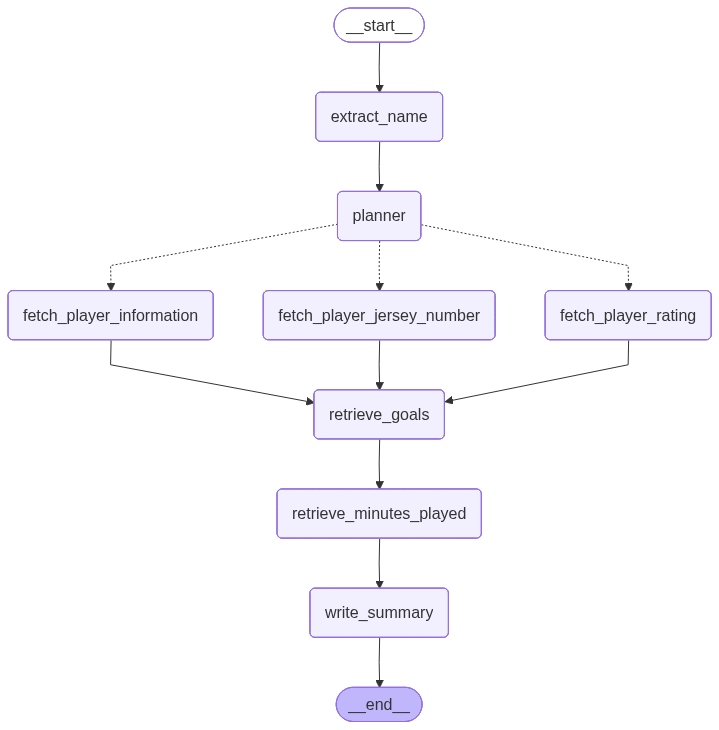

In [19]:
graph = graph_builder.compile()
display_graph(graph)

In [20]:
result = graph.invoke({
    'question': 'Will Haaland be able to win the FIFA World Cup for Norway in 2026 based on his recent performance and stats?'
})

ValidationError: 1 validation error for PlayerState
rating
  Field required [type=missing, input_value={'question': 'Will Haalan...performance and stats?'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing